In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('../data/survey_data.csv')
df.fillna(0,inplace=True)

I_fresh  = ((df["근속년수"] >= 0)  & (df["근속년수"] < 3)).astype(int)
I_junior = ((df["근속년수"] >= 3)  & (df["근속년수"] < 10)).astype(int)
I_middle = ((df["근속년수"] >= 10) & (df["근속년수"] < 20)).astype(int)
I_senior = (df["근속년수"] >= 20).astype(int)

df = df.drop(columns='근속년수')
df["근속년수_구분"] = 1 * I_fresh + 2 * I_junior + 3 * I_middle + 4 * I_senior

CL_map = {'CL1' : 1 , 'CL2' : 2 ,  'CL3' : 3, 'CL4':4}
degree_map = {'고졸' : 1, '학사':2, '석사':2,'박사':3}
group_map = {'A그룹' : 1, 'B그룹' : 2, 'C그룹' : 3,'D그룹' : 4,
             'E그룹' : 5,'F그룹' : 6,'G그룹' : 7,'H그룹' : 8}

## 이직의사는 DataGeneration.py에서 이미 1(이직 의사 없음)~5(매우 높음) 순서형 점수로 생성되므로
## 별도 map 없이 그대로 사용한다.
df['직급'] = df['직급'].map(CL_map)
df['학력'] = df['학력'].map(degree_map)


df_group = pd.DataFrame(df['소속'].map(group_map),columns=['소속'])
#시각화를 위해 별도 분리

df = pd.get_dummies(df, columns=['소속'],drop_first=False)

df.head(10)

,idx,직급,학력,이직의사,조직문화평가_복지,조직문화평가_회의,조직문화평가_교육,조직문화평가_업무,조직문화평가_상사,조직문화평가_부서,...,통합점수_전년대비증감,근속년수_구분,소속_A그룹,소속_B그룹,소속_C그룹,소속_D그룹,소속_E그룹,소속_F그룹,소속_G그룹,소속_H그룹
0,0,4,2,2,4.0,2.0,4.0,3.0,3.0,4.0,...,-2.5,3,True,False,False,False,False,False,False,False
1,1,3,3,2,0.0,0.0,0.0,0.0,0.0,0.0,...,-13.1,3,True,False,False,False,False,False,False,False
2,2,4,2,4,5.0,4.0,4.0,3.0,4.0,5.0,...,-0.9,4,False,True,False,False,False,False,False,False
3,3,4,2,2,0.0,0.0,0.0,0.0,0.0,0.0,...,-6.4,4,False,False,False,False,False,False,False,True
4,4,2,2,4,2.0,2.0,4.0,3.0,3.0,5.0,...,-8.2,2,False,False,False,True,False,False,False,False
5,5,4,2,3,3.0,1.0,1.0,3.0,2.0,4.0,...,-9.9,4,False,False,False,False,False,True,False,False
6,6,4,2,2,3.0,4.0,4.0,5.0,4.0,4.0,...,3.0,4,False,False,False,True,False,False,False,False
7,7,4,1,3,0.0,0.0,0.0,0.0,0.0,0.0,...,-14.8,4,False,True,False,False,False,False,False,False
8,8,2,2,1,4.0,4.0,3.0,3.0,3.0,4.0,...,-8.0,3,False,False,True,False,False,False,False,False
9,9,3,2,3,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.3,3,True,False,False,False,False,False,False,False


In [2]:
TRAIN_FEATURE_SURVEY = ['복지','회의','교육','업무','상사','동료']
TRAIN_FEATURE_IDENTITY = ['직급','학력','근속년수_구분', '소속_A그룹',
       '소속_B그룹', '소속_C그룹', '소속_D그룹', '소속_E그룹', '소속_F그룹', '소속_G그룹', '소속_H그룹']
GROUP_ITER = ['소속_A그룹',
       '소속_B그룹', '소속_C그룹', '소속_D그룹', '소속_E그룹', '소속_F그룹', '소속_G그룹', '소속_H그룹']
df_selection = pd.DataFrame()
for item in TRAIN_FEATURE_SURVEY:
    df_selection[item] = df[f'조직문화평가_{item}']
for item in TRAIN_FEATURE_IDENTITY:
    df_selection[item] = df[item]

df_selection['회의'] = df['1Q_업무몰입도평가_회의'] + df['2Q_업무몰입도평가_회의']
df_selection['업무'] = df['1Q_업무몰입도평가_고객'] + df['2Q_업무몰입도평가_고객'] + df['1Q_업무몰입도평가_기술력'] + df['2Q_업무몰입도평가_기술력']
df_selection['상사'] = df['1Q_업무몰입도평가_보고'] + df['2Q_업무몰입도평가_보고'] + df['1Q_업무몰입도평가_소통'] + df['2Q_업무몰입도평가_소통']
df_selection.head(10)

,복지,회의,교육,업무,상사,동료,직급,학력,근속년수_구분,소속_A그룹,소속_B그룹,소속_C그룹,소속_D그룹,소속_E그룹,소속_F그룹,소속_G그룹,소속_H그룹
0,4.0,0.0,4.0,0.0,0.0,4.0,4,2,3,True,False,False,False,False,False,False,False
1,0.0,3.0,0.0,5.0,8.0,0.0,3,3,3,True,False,False,False,False,False,False,False
2,5.0,6.0,4.0,11.0,9.0,4.0,4,2,4,False,True,False,False,False,False,False,False
3,0.0,0.0,0.0,0.0,0.0,0.0,4,2,4,False,False,False,False,False,False,False,True
4,2.0,6.0,4.0,10.0,13.0,2.0,2,2,2,False,False,False,True,False,False,False,False
5,3.0,5.0,1.0,8.0,6.0,2.0,4,2,4,False,False,False,False,False,True,False,False
6,3.0,0.0,4.0,0.0,0.0,3.0,4,2,4,False,False,False,True,False,False,False,False
7,0.0,0.0,0.0,0.0,0.0,0.0,4,1,4,False,True,False,False,False,False,False,False
8,4.0,4.0,3.0,8.0,8.0,4.0,2,2,3,False,False,True,False,False,False,False,False
9,0.0,3.0,0.0,5.0,7.0,0.0,3,2,3,True,False,False,False,False,False,False,False


In [3]:
X = df_selection[['복지','회의','교육','업무','상사','동료', '직급','학력','근속년수_구분','소속_A그룹',
       '소속_B그룹', '소속_C그룹', '소속_D그룹', '소속_E그룹', '소속_F그룹', '소속_G그룹', '소속_H그룹']]
y = df['이직의사']

X_tn, X_te, y_tn, y_te = train_test_split(X,y,random_state=0,stratify=y)

std = StandardScaler()
std.fit(X_tn)

X_tn_std = std.transform(X_tn)
X_te_std = std.transform(X_te)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rfc = RandomForestClassifier(random_state=0)

rfc.fit(X_tn_std,y_tn)
y_pred_rfc = rfc.predict(X_te_std)

print(rfc.feature_importances_)
report = classification_report(y_te, y_pred_rfc)
print('========RandomForest===========')
print(report)

## 이직의사가 1~5 순서형 점수로 바뀌었으므로, 아래 순위/정확도는 재실행 후 다시 확인한다.

[0.08057879 0.09840243 0.0790323  0.13033561 0.13215446 0.07394904
 0.07595992 0.04154251 0.0785556  0.02440972 0.01984689 0.02380992
 0.02898673 0.03165299 0.02811677 0.02814026 0.02452605]
========RandomForest===========
              precision    recall  f1-score   support

           1       0.38      0.45      0.42        22
           2       0.32      0.30      0.31        23
           3       0.24      0.23      0.23        22
           4       0.21      0.17      0.19        23
           5       0.28      0.30      0.29        23

    accuracy                           0.29       113
   macro avg       0.29      0.29      0.29       113
weighted avg       0.29      0.29      0.29       113



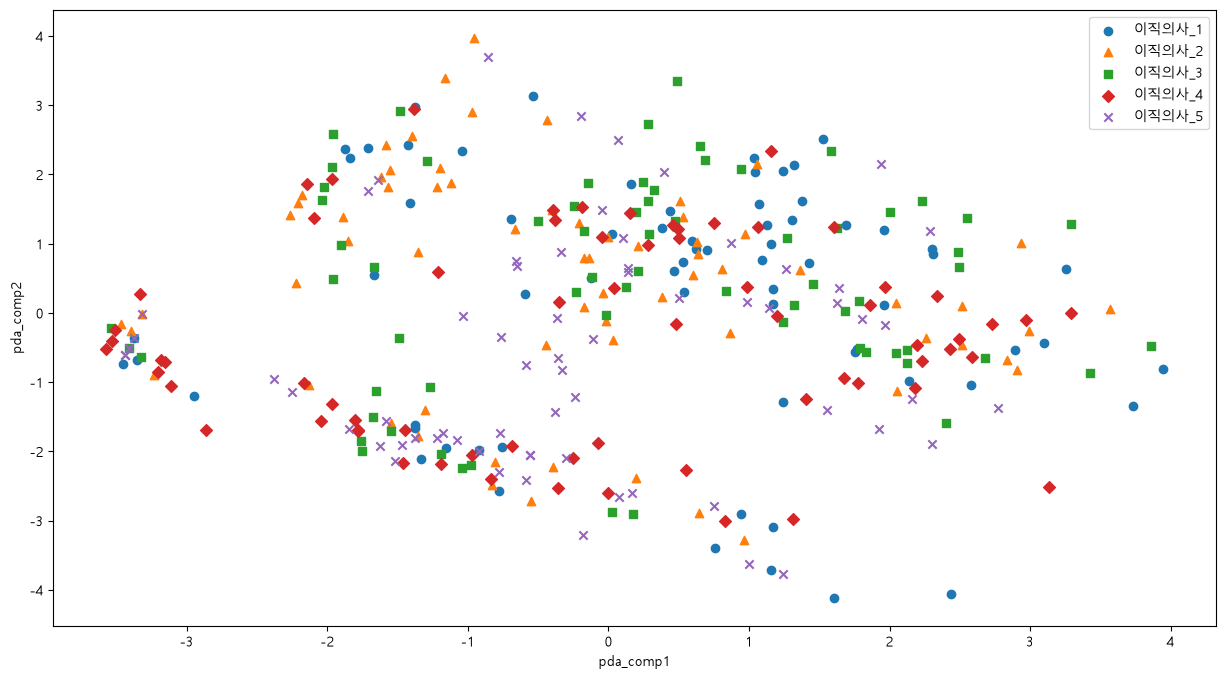

In [5]:
##전체 Feature에 대한 PDA의 수행결과로 인한 2차원 분포
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

pca = PCA(n_components=2)
pca.fit(X_tn_std)

X_tn_pca = pca.transform(X_tn_std)
X_te_pca = pca.transform(X_te_std)

X_tn_pda_df = pd.DataFrame(X_tn_pca, columns=['pda_comp1', 'pda_comp2'])

X_tn_pda_df['target'] = df.loc[X_tn.index, '이직의사'].values

plt.figure(figsize=(15,8))

markers = {1: 'o', 2: '^', 3: 's', 4: 'D', 5: 'x'}

for level in range(1, 6):
    df_level = X_tn_pda_df[X_tn_pda_df['target'] == level]
    plt.scatter(df_level['pda_comp1'], df_level['pda_comp2'],
                marker=markers[level], label=f'이직의사_{level}')

plt.xlabel('pda_comp1')
plt.ylabel('pda_comp2')
plt.legend()
plt.show()

In [6]:
## 소속 및 신원의 LDA와 설문 결과으 LDA로 2차원 분포
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_survey = df_selection[TRAIN_FEATURE_SURVEY]
X_identitiy = df_selection[TRAIN_FEATURE_IDENTITY]
y = df['이직의사']
lda = LinearDiscriminantAnalysis(n_components=1)

X_tn_sur, X_te_sur, y_tn_sur, y_te_sur = train_test_split(X_survey, y, random_state=0, stratify=y)
X_tn_id, X_te_id, y_tn_id, y_te_id = train_test_split(X_identitiy, y, random_state=0, stratify=y)

lda.fit(X_tn_sur, y_tn_sur)
X_tn_lda_sur = lda.transform(X_tn_sur)
X_te_lda_sur = lda.transform(X_te_sur)


lda.fit(X_tn_id, y_tn_id)
X_tn_lda_id = lda.transform(X_tn_id)
X_te_lda_id = lda.transform(X_te_id)

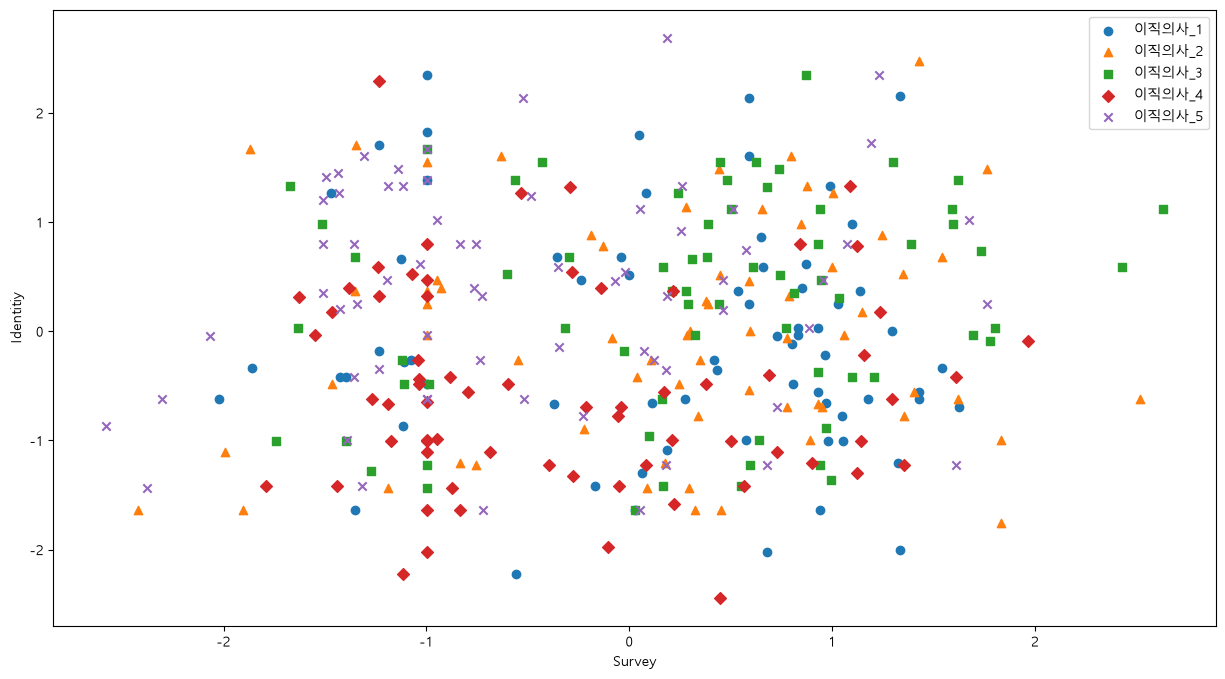

In [7]:
## 2차원으로 LDA축 기준 분포도 시각화

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

X_tn_lda_df = pd.DataFrame(X_tn_lda_sur, columns=['lda_survey'])
X_tn_lda_df['lda_identitiy'] = X_tn_lda_id

X_tn_lda_df['target'] = df.loc[X_tn_sur.index, '이직의사'].values

plt.figure(figsize=(15,8))

markers = {1: 'o', 2: '^', 3: 's', 4: 'D', 5: 'x'}

for level in range(1, 6):
    df_level = X_tn_lda_df[X_tn_lda_df['target'] == level]
    plt.scatter(df_level['lda_survey'], df_level['lda_identitiy'],
                marker=markers[level], label=f'이직의사_{level}')

plt.xlabel('Survey')
plt.ylabel('Identitiy')
plt.legend()
plt.show()

In [8]:
df_group.join(df['이직의사']).mean()
df_group.join(df['이직의사']).groupby('소속')['이직의사'].mean()

소속
1    3.220000
2    2.893617
3    3.039216
4    3.126984
5    2.892308
6    2.803279
7    3.152542
8    2.888889
Name: 이직의사, dtype: float64